<a href="https://colab.research.google.com/github/hobbsandbobs-dotcom/Analytics-Coursework/blob/main/3_SQL_and_R_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Setting up

In [ ]:
import pandas as pd

#Uploading NorthStar's datasets into Colab
from google.colab import files
file_uploaded = files.upload()

Saving vehicles_clean.csv to vehicles_clean.csv
Saving orders_clean.csv to orders_clean.csv
Saving incidents_clean.csv to incidents_clean.csv
Saving hubs_clean.csv to hubs_clean.csv
Saving drivers_clean.csv to drivers_clean.csv
Saving deliveries_clean.csv to deliveries_clean.csv
Saving customers_clean.csv to customers_clean.csv
Saving complaints_clean.csv to complaints_clean.csv
Saving app_events_clean.csv to app_events_clean.csv


In [ ]:
#Python libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#Reloading the cleaned datasets
orders_df = pd.read_csv("orders_clean.csv")
deliveries_df = pd.read_csv("deliveries_clean.csv")
drivers_df = pd.read_csv("drivers_clean.csv")
vehicles_df = pd.read_csv("vehicles_clean.csv")
hubs_df = pd.read_csv("hubs_clean.csv")
incidents_df = pd.read_csv("incidents_clean.csv")
complaints_df = pd.read_csv("complaints_clean.csv")
customers_df = pd.read_csv("customers_clean.csv")
app_events_df = pd.read_csv("app_events_clean.csv")

2. SQL Within R

In [ ]:
#had an error so making sure they are the same type
orders_df["order_id"] = orders_df["order_id"].astype("string")
deliveries_df["order_id"] = deliveries_df["order_id"].astype("string")
app_events_df["order_id"] = app_events_df["order_id"].astype("string")
complaints_df["order_id"] = complaints_df["order_id"].astype("string")

3. R within Colab

In [ ]:
!pip install rpy2

%load_ext rpy2.ipython

In [ ]:

%%R

install.packages(c("sqldf","dplyr", "ggplot2", "ggrepel"), repos="https://cloud.r-project.org")
library(sqldf)
library(dplyr)
library(ggplot2)
library(ggrepel)


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’

trying URL 'https://cloud.r-project.org/src/contrib/gsubfn_0.7.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/proto_1.0.0.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/RSQLite_3.52.0.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/chron_2.3-62.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/sqldf_0.4-12.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/dplyr_1.2.1.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/ggplot2_4.0.3.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/ggrepel_0.9.8.tar.gz'

The downloaded source packages are in
	‘/tmp/RtmphYWLlp/downloaded_packages’
Loading required package: gsubfn
Loading required package: proto
Loading required package: RSQLite

Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:


In [ ]:
%%R -i orders_df -i deliveries_df -i customers_df -i incidents_df -i drivers_df -i vehicles_df -i hubs_df -i app_events_df -i complaints_df

NULL


4. Query 1

In [ ]:
%%R

q1 <- sqldf("
SELECT
    es.event_type,
    COUNT(DISTINCT del.delivery_id) AS deliveries,
    AVG(es.failed_event_rate) * 100 AS failed_event_pct,
    AVG(es.avg_latency) AS avg_latency,
    AVG(CASE WHEN del.delivery_status = 'Failed' THEN 1.0 ELSE 0 END) * 100 AS delivery_failure_rate
FROM (
    SELECT
        order_id,
        event_type,
        COUNT(*) AS event_count,
        AVG(api_latency_ms) AS avg_latency,
        AVG(CASE WHEN success_flag = 0 THEN 1.0 ELSE 0 END) AS failed_event_rate
    FROM app_events_df
    WHERE order_id IS NOT NULL
    GROUP BY order_id, event_type
) AS es
JOIN deliveries_df AS del
  ON es.order_id = del.order_id
GROUP BY es.event_type
")

In [ ]:
%%R

q1

                   event_type deliveries failed_event_pct avg_latency
1              cancel_attempt         15          0.00000    387.8667
2              chat_escalated         17         41.17647    544.0000
3                 chat_opened         51          0.00000    472.4510
4 delivery_instruction_update         42          0.00000    439.3056
5                 eta_refresh         52          0.00000    389.6923
6               payment_retry         37         32.43243    441.6486
7                search_route         60          0.00000    470.5333
8                 track_order         73          0.00000    464.4521
  delivery_failure_rate
1             26.666667
2             17.647059
3             13.725490
4             14.285714
5             17.307692
6             13.513514
7             18.333333
8              6.849315


4.1. Visualisation

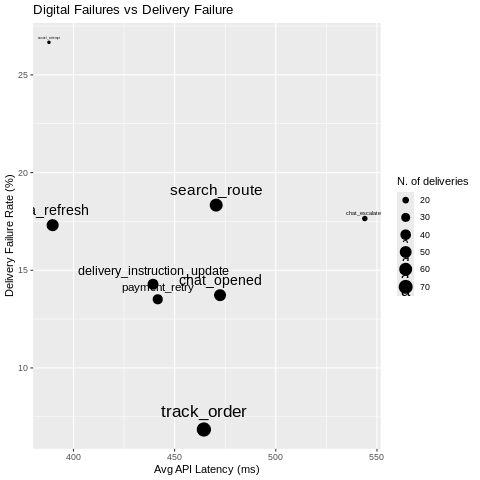

In [ ]:
%%R

ggplot(q1, aes(x = avg_latency,
               y = delivery_failure_rate,
               size = deliveries)) +
  geom_point(alpha = 1) +
  geom_text(aes(label = event_type), vjust = -1) +
  labs(
    title = "Digital Failures vs Delivery Failure",
    x = "Avg API Latency (ms)",
    y = "Delivery Failure Rate (%)",
    size = "N. of deliveries"
  )


4.2. R statistical

In [ ]:
%%R

# Correlation test
cor_test_q1 <- cor.test(
  q1$avg_latency,
  q1$delivery_failure_rate
)

cor_test_q1


	Pearson's product-moment correlation

data:  q1$avg_latency and q1$delivery_failure_rate
t = -0.90231, df = 6, p-value = 0.4017
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.8446063  0.4746188
sample estimates:
       cor 
-0.3456607 



In [ ]:
%%R
 model_q1 <- lm(delivery_failure_rate ~ avg_latency + failed_event_pct, data = q1)

summary(model_q1)

confint(model_q1)

                       2.5 %       97.5 %
(Intercept)      -22.6822654 103.82915393
avg_latency       -0.2006121   0.08831152
failed_event_pct  -0.3342003   0.50920585


5. SQL Query 2

In [ ]:
%%R

q2 <- sqldf("
SELECT
    veh.vehicle_type,
    veh.maintenance_status,

    COUNT(deliv.delivery_id) AS total_deliveries,

    AVG(CASE WHEN deliv.delivery_status = 'Failed' THEN 1.0 ELSE 0 END) * 100 AS failure_rate,
    AVG(CASE WHEN deliv.delivery_status = 'Delayed' THEN 1.0 ELSE 0 END) * 100 AS delay_rate,

    AVG(veh.battery_health_pct) AS avg_battery,
    AVG(deliv.manual_route_override_count) AS avg_overrides,
    AVG(deliv.fuel_or_charge_cost) AS avg_cost

FROM deliveries_df deliv
LEFT JOIN vehicles_df veh
    ON deliv.vehicle_id = veh.vehicle_id

WHERE veh.vehicle_type IS NOT NULL
  AND veh.maintenance_status IS NOT NULL

GROUP BY veh.vehicle_type, veh.maintenance_status
")

In [ ]:
%%R
q2

   vehicle_type maintenance_status total_deliveries failure_rate delay_rate
1      CargoVan             Active              117     9.401709   24.78632
2      CargoVan           InRepair               68    32.352941   23.52941
3      CargoVan          Scheduled               38    13.157895   21.05263
4        Diesel             Active               80    10.000000   13.75000
5        Diesel           InRepair               55    30.909091   20.00000
6        Diesel          Scheduled                9    11.111111   11.11111
7            EV             Active              214     5.140187   22.42991
8            EV           InRepair               60    28.333333   23.33333
9            EV          Scheduled               65     3.076923   18.46154
10       Hybrid             Active              131    11.450382   19.08397
11       Hybrid           InRepair               71    29.577465   15.49296
12       Hybrid          Scheduled               42     4.761905   38.09524
   avg_batte

5.1. Visualisation

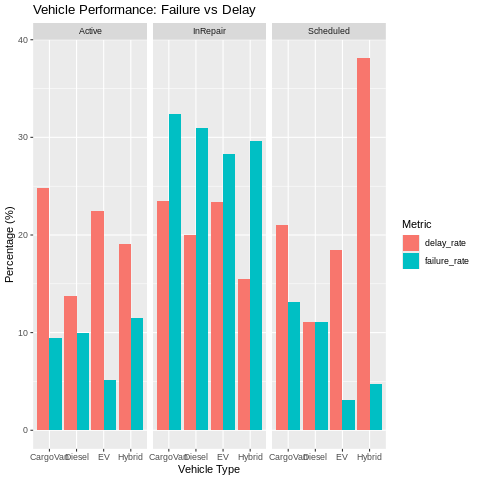

In [ ]:
%%R


q2_long <- q2 %>%
  tidyr::pivot_longer(
    cols = c(failure_rate, delay_rate),
    names_to = "metric",
    values_to = "percentage"
  )

ggplot(q2_long, aes(x = vehicle_type, y = percentage, fill = metric)) +
  geom_bar(stat = "identity", position = "dodge") +
  facet_wrap(~maintenance_status) +
  labs(
    title = "Vehicle Performance: Failure and Delay",
    x = "Vehicle Type",
    y = "Percentage %",
    fill = "Metric"
  )

5.2. R stats

In [ ]:
%%R
#looking at how failure rate and vehicle type are related
anova_q2 <- aov(failure_rate ~ vehicle_type, data = q2)
summary(anova_q2)


             Df Sum Sq Mean Sq F value Pr(>F)
vehicle_type  3     66   22.01   0.135  0.936
Residuals     8   1303  162.87               


6. SQL Query 3

In [ ]:
%%R

q3 <- sqldf("
SELECT
    o.priority_level,
    d.delivery_status,

    COUNT(DISTINCT d.delivery_id) AS deliveries,
    COUNT(DISTINCT comp.complaint_id) AS complaints,

    COUNT(DISTINCT comp.complaint_id) * 1.0 /
    COUNT(DISTINCT d.delivery_id) AS complaint_rate,

    AVG(d.customer_rating_post_delivery) AS avg_rating,

    AVG(comp.compensation_amount) AS avg_compensation,
    SUM(comp.compensation_amount) AS total_compensation

FROM orders_df o
LEFT JOIN deliveries_df d
    ON o.order_id = d.order_id
LEFT JOIN complaints_df comp
    ON o.order_id = comp.order_id

GROUP BY o.priority_level, d.delivery_status
")


In [ ]:
%%R

q3

   priority_level delivery_status deliveries complaints complaint_rate
1        Critical            <NA>          0          3             NA
2        Critical         Delayed         15          5      0.3333333
3        Critical          Failed          3          0      0.0000000
4        Critical          OnTime         56         14      0.2500000
5            High            <NA>          0         26             NA
6            High         Delayed         46         11      0.2391304
7            High          Failed         32          7      0.2187500
8            High          OnTime        153         36      0.2352941
9             Low            <NA>          0         25             NA
10            Low         Delayed         53         12      0.2264151
11            Low          Failed         34         11      0.3235294
12            Low          OnTime        172         36      0.2093023
13         Medium            <NA>          0         34             NA
14    

6.1. Visualisation

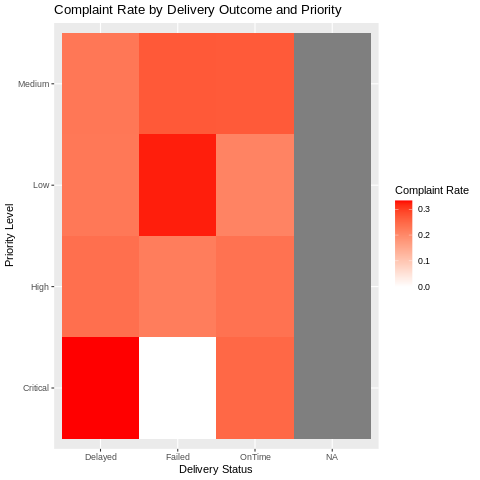

In [ ]:
%%R

ggplot(q3, aes(x = delivery_status,
               y = priority_level,
               fill = complaint_rate)) +
  geom_tile() +
  scale_fill_gradient(low = "white", high = "red") +
  labs(
    title = "Complaint Rate by delivery outcome and priority",
    x = "Delivery Status",
    y = "Priority Level",
    fill = "Complaint Rate"
  )

6.2. R stats

In [ ]:
%%R

q3_grouped <- q3 %>%
  mutate(status_group = ifelse(delivery_status == "Failed", "Failed", "Other"))

t_test_q3 <- t.test(total_compensation ~ status_group, data = q3_grouped)

t_test_q3



	Welch Two Sample t-test

data:  total_compensation by status_group
t = -1.0447, df = 8.91, p-value = 0.3237
alternative hypothesis: true difference in means between group Failed and group Other is not equal to 0
95 percent confidence interval:
 -464.9855  171.4988
sample estimates:
mean in group Failed  mean in group Other 
            297.1267             443.8700 

